# Binomial Tree Option Pricing

## The Cox-Ross-Rubinstein (CRR) Model

In previous chapters, we priced options using Monte Carlo simulation — either direct Feynman-Kac (Chapter 4) or Longstaff-Schwartz regression (Chapter 5). Here we take a fundamentally different approach: **build a discrete lattice** of possible stock prices and work backward through the tree.

The CRR binomial model (Cox, Ross, and Rubinstein, 1979) discretizes the continuous GBM process into a **recombining binomial tree**. At each time step $\Delta t = T/N$, the stock price either:
- Moves **up** by factor $u = e^{\sigma\sqrt{\Delta t}}$
- Moves **down** by factor $d = e^{-\sigma\sqrt{\Delta t}} = 1/u$

The **risk-neutral probability** of an up move is:

$$p = \frac{e^{r\Delta t} - d}{u - d}$$

This ensures the expected return matches the risk-free rate. As $N \to \infty$, the binomial model converges to Black-Scholes.

### Why Trees?

The binomial tree makes the **backward induction** for American options completely transparent: at each node, you compare the intrinsic value (exercise now) with the discounted expected value of the two child nodes (continue holding). No regression needed — the continuation value is computed exactly on the lattice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, log, sqrt, exp
%matplotlib inline

# Black-Scholes analytical formulas for comparison
def bs_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S * bs_cdf(d1) - K * exp(-r*T) * bs_cdf(d2)

def bs_put(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return -S * bs_cdf(-d1) + K * exp(-r*T) * bs_cdf(-d2)

## 1. Building the CRR Binomial Tree

The recombining property ($ud = 1$) means that after $n$ steps, there are only $n+1$ distinct price levels instead of $2^n$. At step $k$, node $j$ has price:

$$S_{k,j} = S_0 \, u^j \, d^{k-j} = S_0 \, u^{2j - k}, \quad j = 0, 1, \ldots, k$$

This makes the tree computationally efficient — $O(N^2)$ storage instead of $O(2^N)$.

In [2]:
def crr_tree(S0, r, sigma, T, N):
    """
    Build a CRR binomial tree.
    
    Returns: (stock_tree, u, d, p, dt)
        stock_tree: list of arrays, stock_tree[k] has k+1 prices at step k
        u, d: up/down factors
        p: risk-neutral up probability
        dt: time step size
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Build stock price tree
    # At step k, node j: S = S0 * u^j * d^(k-j)
    stock_tree = []
    for k in range(N + 1):
        j = np.arange(k + 1)
        prices = S0 * u**j * d**(k - j)
        stock_tree.append(prices)
    
    return stock_tree, u, d, p, dt

# Example: small tree for visualization
S0, K, r, T, sigma = 100, 100, 0.05, 1.0, 0.2
N_small = 4
tree, u, d, p, dt = crr_tree(S0, r, sigma, T, N_small)

print(f"CRR parameters: u = {u:.6f}, d = {d:.6f}, p = {p:.6f}, dt = {dt:.4f}")
print(f"Verify: u*d = {u*d:.10f} (should be 1)")
print(f"\nStock price tree (N={N_small}):")
for k in range(N_small + 1):
    prices_str = '  '.join(f'{s:8.2f}' for s in tree[k])
    print(f"  t={k}: {prices_str}")

CRR parameters: u = 1.105171, d = 0.904837, p = 0.537808, dt = 0.2500
Verify: u*d = 1.0000000000 (should be 1)

Stock price tree (N=4):
  t=0:   100.00
  t=1:    90.48    110.52
  t=2:    81.87    100.00    122.14
  t=3:    74.08     90.48    110.52    134.99
  t=4:    67.03     81.87    100.00    122.14    149.18


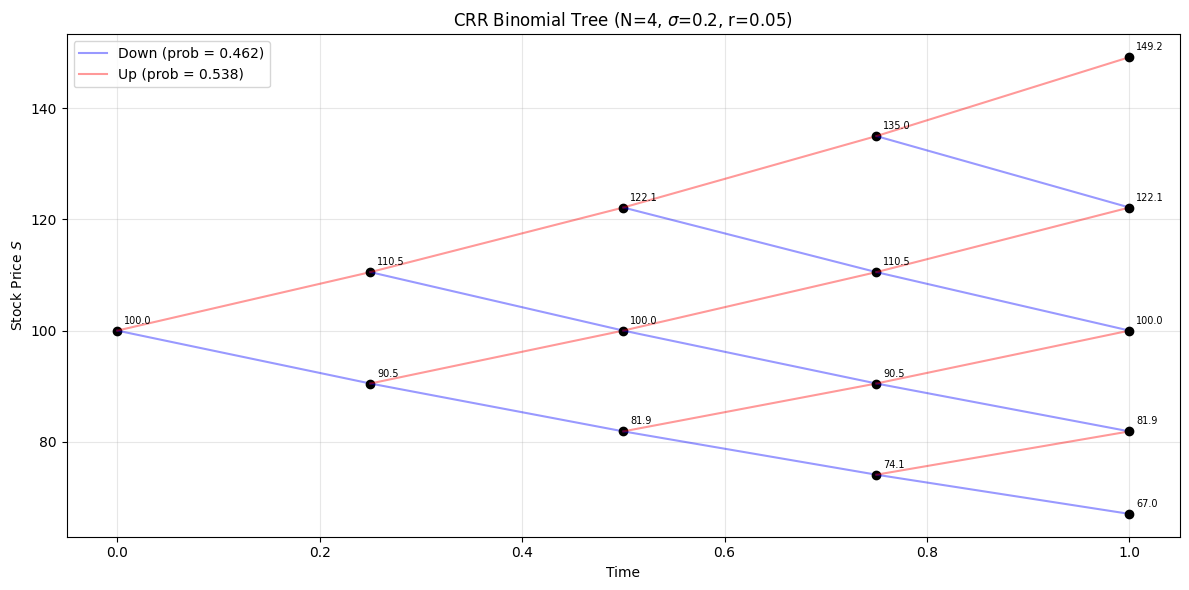

In [3]:
# Visualize the binomial tree
fig, ax = plt.subplots(figsize=(12, 6))
t_nodes = np.linspace(0, T, N_small + 1)

for k in range(N_small + 1):
    for j in range(k + 1):
        # Plot node
        ax.plot(t_nodes[k], tree[k][j], 'ko', markersize=6)
        ax.annotate(f'{tree[k][j]:.1f}', (t_nodes[k], tree[k][j]),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)
        # Draw edges to children
        if k < N_small:
            ax.plot([t_nodes[k], t_nodes[k+1]], [tree[k][j], tree[k+1][j]], 'b-', alpha=0.4)
            ax.plot([t_nodes[k], t_nodes[k+1]], [tree[k][j], tree[k+1][j+1]], 'r-', alpha=0.4)

ax.set_xlabel('Time')
ax.set_ylabel('Stock Price $S$')
ax.set_title(f'CRR Binomial Tree (N={N_small}, $\\sigma$={sigma}, r={r})')
ax.plot([], [], 'b-', alpha=0.4, label=f'Down (prob = {1-p:.3f})')
ax.plot([], [], 'r-', alpha=0.4, label=f'Up (prob = {p:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. European Option Pricing via Backward Induction

To price a European option on the tree:

1. **Terminal condition**: At step $N$, option value = payoff at each node
2. **Backward step**: At step $k$, the option value at node $j$ is the discounted expected value of the two children:

$$V_{k,j} = e^{-r\Delta t}\left[p \, V_{k+1,j+1} + (1-p) \, V_{k+1,j}\right]$$

3. **Price**: $V_{0,0}$ is the option price at time 0.

In [4]:
def binomial_european(S0, K, r, sigma, T, N, option_type='put'):
    """
    Price a European option using the CRR binomial tree.
    
    Returns: option price
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    
    # Terminal stock prices at step N
    j = np.arange(N + 1)
    S_T = S0 * u**j * d**(N - j)
    
    # Terminal payoff
    if option_type == 'call':
        V = np.maximum(S_T - K, 0)
    else:
        V = np.maximum(K - S_T, 0)
    
    # Backward induction
    for k in range(N - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
    
    return V[0]

# Compare with Black-Scholes
N_test = 200
euro_call_tree = binomial_european(S0, K, r, sigma, T, N_test, 'call')
euro_put_tree = binomial_european(S0, K, r, sigma, T, N_test, 'put')
euro_call_bs = bs_call(S0, K, r, T, sigma)
euro_put_bs = bs_put(S0, K, r, T, sigma)

print(f"=== European Option Prices (N={N_test}) ===")
print(f"{'':15s} {'BS Analytical':>14s} {'Binomial Tree':>14s} {'Difference':>12s}")
print(f"{'Call':15s} {euro_call_bs:14.6f} {euro_call_tree:14.6f} {euro_call_tree - euro_call_bs:12.6f}")
print(f"{'Put':15s} {euro_put_bs:14.6f} {euro_put_tree:14.6f} {euro_put_tree - euro_put_bs:12.6f}")

=== European Option Prices (N=200) ===
                 BS Analytical  Binomial Tree   Difference
Call                 10.450584      10.440591    -0.009992
Put                   5.573526       5.563534    -0.009992


## 3. Convergence to Black-Scholes

As $N \to \infty$, the CRR binomial price converges to the Black-Scholes price. The convergence is $O(1/N)$ but exhibits an **oscillatory pattern** — odd and even $N$ converge from different sides.

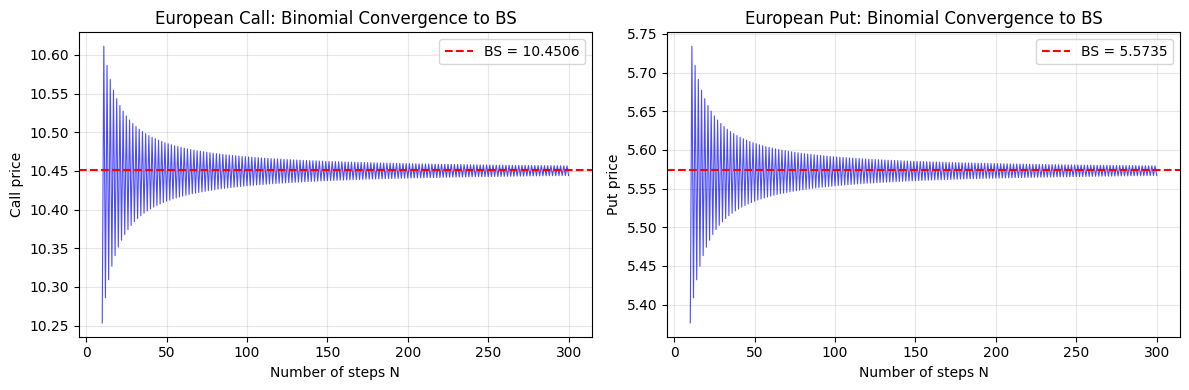

Error at N=50:  0.039892
Error at N=100: 0.019972
Error at N=200: 0.009992
Error at N=300: 0.006663


In [5]:
N_values = np.arange(10, 301)
call_prices = [binomial_european(S0, K, r, sigma, T, n, 'call') for n in N_values]
put_prices = [binomial_european(S0, K, r, sigma, T, n, 'put') for n in N_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(N_values, call_prices, 'b-', alpha=0.7, linewidth=0.8)
ax1.axhline(euro_call_bs, color='r', linestyle='--', linewidth=1.5, label=f'BS = {euro_call_bs:.4f}')
ax1.set_xlabel('Number of steps N')
ax1.set_ylabel('Call price')
ax1.set_title('European Call: Binomial Convergence to BS')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(N_values, put_prices, 'b-', alpha=0.7, linewidth=0.8)
ax2.axhline(euro_put_bs, color='r', linestyle='--', linewidth=1.5, label=f'BS = {euro_put_bs:.4f}')
ax2.set_xlabel('Number of steps N')
ax2.set_ylabel('Put price')
ax2.set_title('European Put: Binomial Convergence to BS')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show convergence rate
errors = np.abs(np.array(call_prices) - euro_call_bs)
print(f"Error at N=50:  {errors[40]:.6f}")
print(f"Error at N=100: {errors[90]:.6f}")
print(f"Error at N=200: {errors[190]:.6f}")
print(f"Error at N=300: {errors[290]:.6f}")

## 4. American Option Pricing

The binomial tree handles American options naturally. At each node during backward induction, we compare:
- **Continuation value**: $C_{k,j} = e^{-r\Delta t}[p \, V_{k+1,j+1} + (1-p) \, V_{k+1,j}]$
- **Intrinsic value** (exercise now): $E_{k,j} = \text{payoff}(S_{k,j})$

The option value is:

$$V_{k,j} = \max(E_{k,j}, \, C_{k,j})$$

This is cleaner than Longstaff-Schwartz — no regression needed, no simulation noise. The continuation value is computed **exactly** on the lattice.

In [6]:
def binomial_american(S0, K, r, sigma, T, N, option_type='put'):
    """
    Price an American option using the CRR binomial tree.
    
    Returns: (price, exercise_boundary)
        price: option price at t=0
        exercise_boundary: array of critical stock prices at each step
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    
    # Terminal stock prices
    j = np.arange(N + 1)
    S_T = S0 * u**j * d**(N - j)
    
    # Terminal payoff
    if option_type == 'call':
        payoff = lambda S: np.maximum(S - K, 0)
    else:
        payoff = lambda S: np.maximum(K - S, 0)
    
    V = payoff(S_T)
    exercise_boundary = np.full(N + 1, np.nan)
    
    # Backward induction with early exercise check
    for k in range(N - 1, -1, -1):
        j = np.arange(k + 1)
        S_k = S0 * u**j * d**(k - j)
        
        # Continuation value
        cont = disc * (p * V[1:] + (1 - p) * V[:-1])
        
        # Intrinsic value
        intrinsic = payoff(S_k)
        
        # Exercise if intrinsic > continuation
        exercise = intrinsic > cont
        V = np.where(exercise, intrinsic, cont)
        
        # Record exercise boundary
        if np.any(exercise):
            if option_type == 'put':
                exercise_boundary[k] = np.max(S_k[exercise])
            else:
                exercise_boundary[k] = np.min(S_k[exercise])
    
    return V[0], exercise_boundary

# Price American options
N_amer = 200
amer_put_price, put_boundary = binomial_american(S0, K, r, sigma, T, N_amer, 'put')
amer_call_price, call_boundary = binomial_american(S0, K, r, sigma, T, N_amer, 'call')

print(f"=== American vs European Prices (N={N_amer}) ===")
print(f"{'':20s} {'European (BS)':>14s} {'American (Tree)':>16s} {'Premium':>10s}")
print(f"{'Put':20s} {euro_put_bs:14.6f} {amer_put_price:16.6f} {amer_put_price - euro_put_bs:10.6f}")
print(f"{'Call':20s} {euro_call_bs:14.6f} {amer_call_price:16.6f} {amer_call_price - euro_call_bs:10.6f}")
print()
print("American call premium ~ 0: no early exercise for non-dividend stocks")
print(f"American put premium > 0: early exercise is sometimes optimal")

=== American vs European Prices (N=200) ===
                      European (BS)  American (Tree)    Premium
Put                        5.573526         6.086383   0.512857
Call                      10.450584        10.440591  -0.009992

American call premium ~ 0: no early exercise for non-dividend stocks
American put premium > 0: early exercise is sometimes optimal


## 5. Visualizing the Early Exercise Boundary

The **exercise boundary** $S^*(t)$ divides the $(t, S)$ plane into two regions:
- **Exercise region**: $S < S^*(t)$ for puts — exercise immediately
- **Continuation region**: $S > S^*(t)$ — keep holding

The boundary rises toward $K$ as $t \to T$: near expiry, only very deep ITM puts justify early exercise.

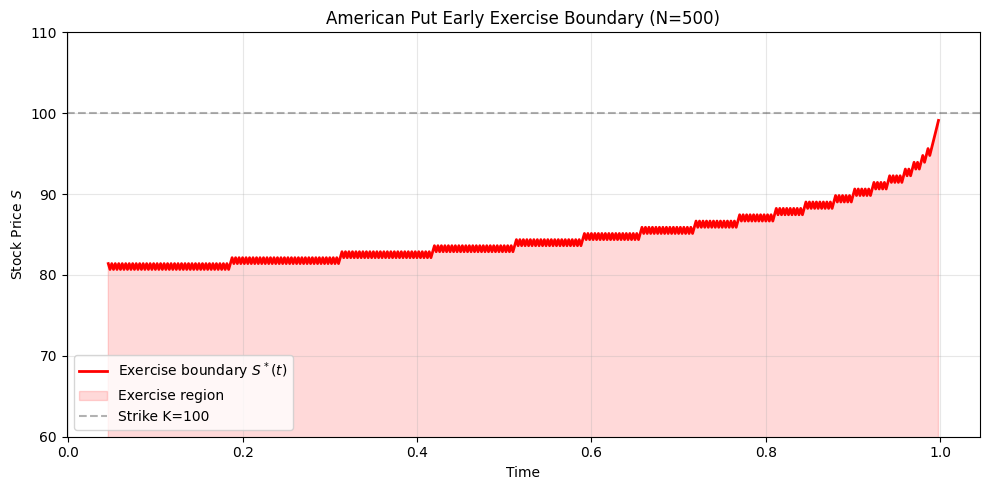

In [7]:
# Compute with fine grid for smooth boundary
N_fine = 500
_, boundary_fine = binomial_american(S0, K, r, sigma, T, N_fine, 'put')
t_grid = np.linspace(0, T, N_fine + 1)

fig, ax = plt.subplots(figsize=(10, 5))

valid = ~np.isnan(boundary_fine)
ax.plot(t_grid[valid], boundary_fine[valid], 'r-', linewidth=2, label=r'Exercise boundary $S^*(t)$')
ax.fill_between(t_grid[valid], 0, boundary_fine[valid], alpha=0.15, color='red', label='Exercise region')
ax.axhline(K, color='k', linestyle='--', alpha=0.3, label=f'Strike K={K}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock Price $S$')
ax.set_title(f'American Put Early Exercise Boundary (N={N_fine})')
ax.set_ylim(60, 110)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

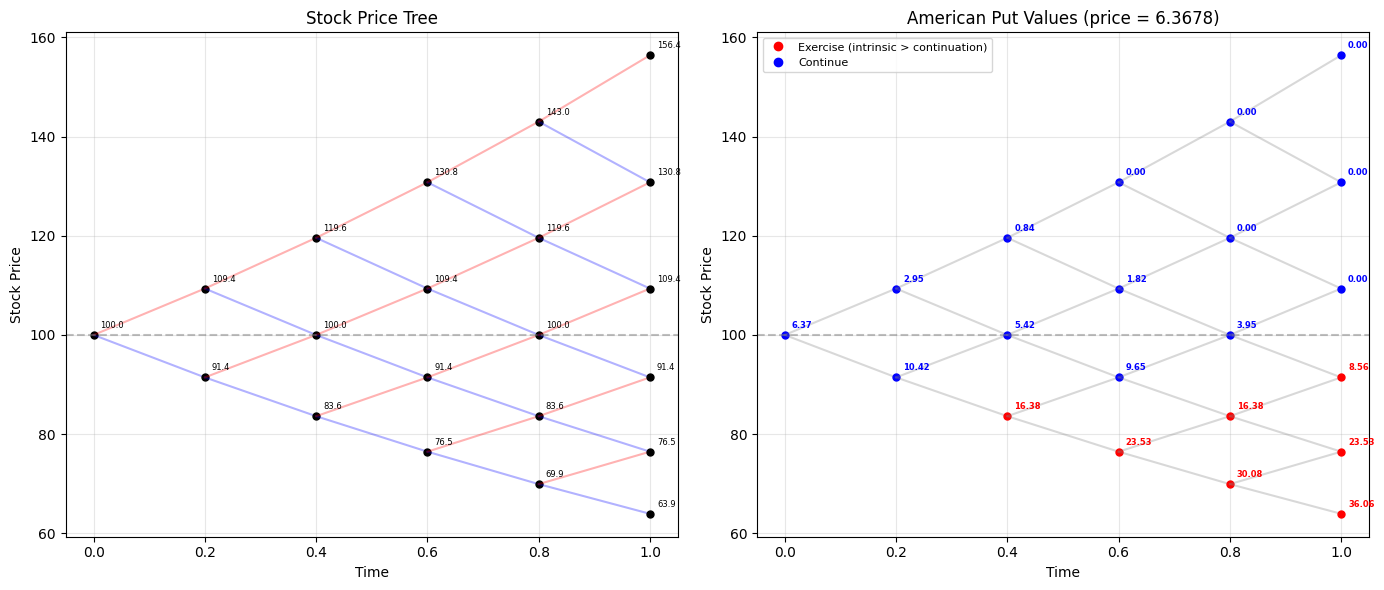

In [8]:
# Visualize backward induction on a small tree
N_vis = 5
tree_vis, u_vis, d_vis, p_vis, dt_vis = crr_tree(S0, r, sigma, T, N_vis)
disc_vis = np.exp(-r * dt_vis)

# Compute option values and exercise decisions
put_values = [None] * (N_vis + 1)
exercise_flags = [None] * (N_vis + 1)

# Terminal
put_values[N_vis] = np.maximum(K - tree_vis[N_vis], 0)
exercise_flags[N_vis] = put_values[N_vis] > 0

# Backward
for k in range(N_vis - 1, -1, -1):
    cont = disc_vis * (p_vis * put_values[k+1][1:] + (1 - p_vis) * put_values[k+1][:-1])
    intrinsic = np.maximum(K - tree_vis[k], 0)
    exercise = intrinsic > cont
    put_values[k] = np.where(exercise, intrinsic, cont)
    exercise_flags[k] = exercise

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
t_nodes = np.linspace(0, T, N_vis + 1)

# Left: stock price tree
for k in range(N_vis + 1):
    for j in range(k + 1):
        ax1.plot(t_nodes[k], tree_vis[k][j], 'ko', markersize=5)
        ax1.annotate(f'{tree_vis[k][j]:.1f}', (t_nodes[k], tree_vis[k][j]),
                    textcoords='offset points', xytext=(5, 5), fontsize=6)
        if k < N_vis:
            ax1.plot([t_nodes[k], t_nodes[k+1]], [tree_vis[k][j], tree_vis[k+1][j]], 'b-', alpha=0.3)
            ax1.plot([t_nodes[k], t_nodes[k+1]], [tree_vis[k][j], tree_vis[k+1][j+1]], 'r-', alpha=0.3)
ax1.axhline(K, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.set_title('Stock Price Tree')
ax1.grid(alpha=0.3)

# Right: option value tree with exercise highlighting
for k in range(N_vis + 1):
    for j in range(k + 1):
        color = 'red' if exercise_flags[k][j] else 'blue'
        ax2.plot(t_nodes[k], tree_vis[k][j], 'o', color=color, markersize=5)
        ax2.annotate(f'{put_values[k][j]:.2f}', (t_nodes[k], tree_vis[k][j]),
                    textcoords='offset points', xytext=(5, 5), fontsize=6,
                    color=color, fontweight='bold')
        if k < N_vis:
            ax2.plot([t_nodes[k], t_nodes[k+1]], [tree_vis[k][j], tree_vis[k+1][j]], '-', color='gray', alpha=0.3)
            ax2.plot([t_nodes[k], t_nodes[k+1]], [tree_vis[k][j], tree_vis[k+1][j+1]], '-', color='gray', alpha=0.3)

ax2.axhline(K, color='gray', linestyle='--', alpha=0.5)
ax2.plot([], [], 'o', color='red', label='Exercise (intrinsic > continuation)')
ax2.plot([], [], 'o', color='blue', label='Continue')
ax2.set_xlabel('Time')
ax2.set_ylabel('Stock Price')
ax2.set_title(f'American Put Values (price = {put_values[0][0]:.4f})')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Early Exercise Premium vs Moneyness

The early exercise premium (American price minus European price) varies with moneyness. Deep in-the-money puts have the largest premium — receiving $K - S$ now and investing at rate $r$ beats waiting.

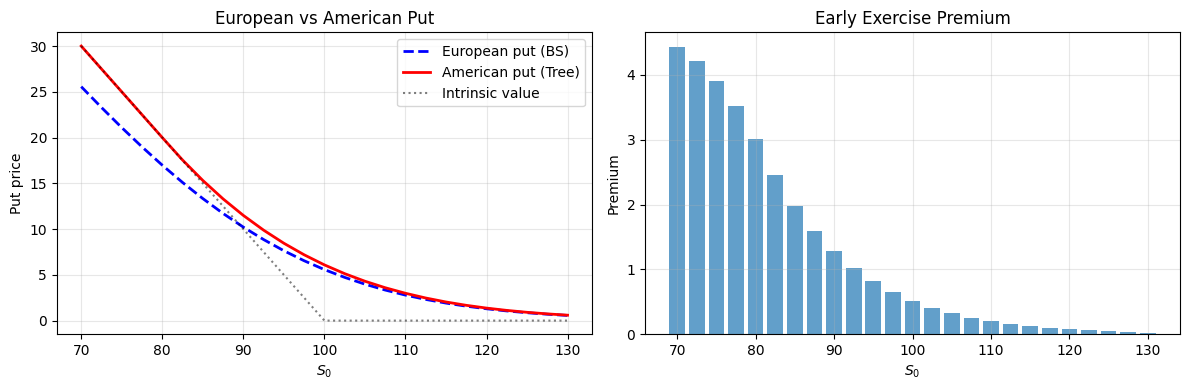

In [9]:
S0_range = np.linspace(70, 130, 25)
N_price = 300
euro_puts = [bs_put(s, K, r, T, sigma) for s in S0_range]
amer_puts = [binomial_american(s, K, r, sigma, T, N_price, 'put')[0] for s in S0_range]

euro_puts = np.array(euro_puts)
amer_puts = np.array(amer_puts)
premiums = amer_puts - euro_puts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(S0_range, euro_puts, 'b--', linewidth=2, label='European put (BS)')
ax1.plot(S0_range, amer_puts, 'r-', linewidth=2, label='American put (Tree)')
ax1.plot(S0_range, np.maximum(K - S0_range, 0), 'k:', alpha=0.5, label='Intrinsic value')
ax1.set_xlabel(r'$S_0$')
ax1.set_ylabel('Put price')
ax1.set_title('European vs American Put')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(S0_range, premiums, width=2, alpha=0.7)
ax2.set_xlabel(r'$S_0$')
ax2.set_ylabel('Premium')
ax2.set_title('Early Exercise Premium')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Comparison: Binomial Tree vs Longstaff-Schwartz

Chapter 5 priced American puts using Monte Carlo with Longstaff-Schwartz regression. Let's compare the two approaches on convergence and accuracy.

- **Binomial tree**: Deterministic, no simulation noise, converges as $O(1/N)$
- **LSM**: Stochastic, subject to regression error, converges as $O(1/\sqrt{N_{\text{paths}}})$

We use the binomial tree with large $N$ as the reference price.

Reference American put price (N=2000): 6.089990


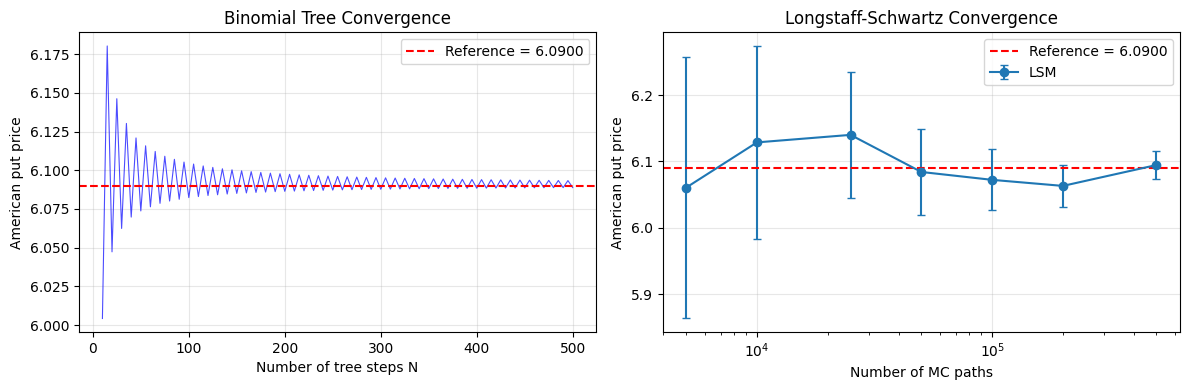


Method                    Price      Error
Tree (N=500)           6.088810   0.001180
LSM (500k paths)       6.094650   0.004660


In [10]:
# Reference price from a very fine binomial tree
N_ref = 2000
ref_price, _ = binomial_american(S0, K, r, sigma, T, N_ref, 'put')
print(f"Reference American put price (N={N_ref}): {ref_price:.6f}")

# Binomial tree convergence
N_tree_vals = np.arange(10, 501, 5)
tree_prices = [binomial_american(S0, K, r, sigma, T, n, 'put')[0] for n in N_tree_vals]
tree_errors = np.abs(np.array(tree_prices) - ref_price)

# LSM convergence (vary number of paths)
def lsm_american_put(S0, K, r, sigma, T, n_steps, n_paths, poly_degree=3):
    """Longstaff-Schwartz pricer for American put."""
    dt = T / n_steps
    Z = np.random.randn(n_steps, n_paths)
    log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S = np.log(S0) + np.cumsum(log_inc, axis=0)
    S = np.exp(np.vstack([np.full((1, n_paths), np.log(S0)), log_S]))
    
    cashflow = np.maximum(K - S[-1], 0)
    exercise_time = np.full(n_paths, n_steps)
    
    for k in range(n_steps - 1, 0, -1):
        intrinsic = np.maximum(K - S[k], 0)
        itm = intrinsic > 0
        if np.sum(itm) == 0:
            continue
        steps_ahead = exercise_time[itm] - k
        Y = cashflow[itm] * np.exp(-r * dt * steps_ahead)
        X_norm = S[k, itm] / K
        basis = np.column_stack([X_norm**p for p in range(poly_degree + 1)])
        coeffs, _, _, _ = np.linalg.lstsq(basis, Y, rcond=None)
        cont_val = basis @ coeffs
        exercise = intrinsic[itm] > cont_val
        idx = np.where(itm)[0][exercise]
        cashflow[idx] = intrinsic[itm][exercise]
        exercise_time[idx] = k
    
    discounted = cashflow * np.exp(-r * dt * exercise_time)
    return np.mean(discounted), np.std(discounted) / np.sqrt(n_paths)

np.random.seed(42)
path_counts = [5000, 10000, 25000, 50000, 100000, 200000, 500000]
lsm_prices = []
lsm_errors = []
for n_p in path_counts:
    price, se = lsm_american_put(S0, K, r, sigma, T, 50, n_p)
    lsm_prices.append(price)
    lsm_errors.append(se)

lsm_prices = np.array(lsm_prices)
lsm_errors_arr = np.array(lsm_errors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Tree convergence
ax1.plot(N_tree_vals, tree_prices, 'b-', alpha=0.7, linewidth=0.8)
ax1.axhline(ref_price, color='r', linestyle='--', label=f'Reference = {ref_price:.4f}')
ax1.set_xlabel('Number of tree steps N')
ax1.set_ylabel('American put price')
ax1.set_title('Binomial Tree Convergence')
ax1.legend()
ax1.grid(alpha=0.3)

# LSM convergence
ax2.errorbar(path_counts, lsm_prices, yerr=2*lsm_errors_arr, fmt='o-', capsize=3, label='LSM')
ax2.axhline(ref_price, color='r', linestyle='--', label=f'Reference = {ref_price:.4f}')
ax2.set_xscale('log')
ax2.set_xlabel('Number of MC paths')
ax2.set_ylabel('American put price')
ax2.set_title('Longstaff-Schwartz Convergence')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'Method':20s} {'Price':>10s} {'Error':>10s}")
print(f"{'Tree (N=500)':20s} {tree_prices[-1]:10.6f} {tree_errors[-1]:10.6f}")
print(f"{'LSM (500k paths)':20s} {lsm_prices[-1]:10.6f} {abs(lsm_prices[-1] - ref_price):10.6f}")

## 8. Effect of Volatility and Time to Expiry

How do the early exercise premium and boundary change with $\sigma$ and $T$?

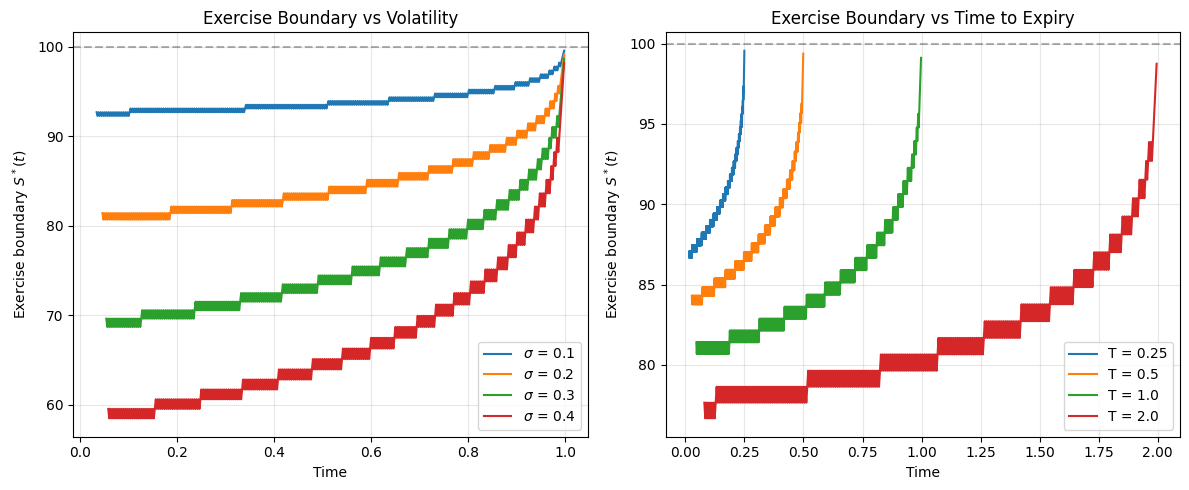

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
N_param = 500

# Varying volatility
sigmas = [0.1, 0.2, 0.3, 0.4]
for sig in sigmas:
    _, bnd = binomial_american(S0, K, r, sig, T, N_param, 'put')
    t_g = np.linspace(0, T, N_param + 1)
    valid = ~np.isnan(bnd)
    ax1.plot(t_g[valid], bnd[valid], linewidth=1.5, label=rf'$\sigma$ = {sig}')

ax1.axhline(K, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('Time')
ax1.set_ylabel(r'Exercise boundary $S^*(t)$')
ax1.set_title('Exercise Boundary vs Volatility')
ax1.legend()
ax1.grid(alpha=0.3)

# Varying time to expiry
T_values = [0.25, 0.5, 1.0, 2.0]
for T_val in T_values:
    _, bnd = binomial_american(S0, K, r, sigma, T_val, N_param, 'put')
    t_g = np.linspace(0, T_val, N_param + 1)
    valid = ~np.isnan(bnd)
    ax2.plot(t_g[valid], bnd[valid], linewidth=1.5, label=f'T = {T_val}')

ax2.axhline(K, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time')
ax2.set_ylabel(r'Exercise boundary $S^*(t)$')
ax2.set_title('Exercise Boundary vs Time to Expiry')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The CRR binomial tree provides a simple, deterministic lattice method for option pricing:

| Property | Binomial Tree | Monte Carlo (LSM) |
|----------|:------------:|:-----------------:|
| Nature | Deterministic lattice | Stochastic simulation |
| American options | Exact backward induction | Regression approximation |
| Convergence | $O(1/N)$ oscillatory | $O(1/\sqrt{N_{\text{paths}}})$ |
| Computation | $O(N^2)$ | $O(N_{\text{steps}} \times N_{\text{paths}})$ |
| High dimensions | Curse of dimensionality | Scales well |
| Exercise boundary | Directly from lattice | Estimated from simulation |

Key takeaways:
- CRR parameters $u = e^{\sigma\sqrt{\Delta t}}$, $d = 1/u$, $p = \frac{e^{r\Delta t} - d}{u - d}$ ensure convergence to Black-Scholes
- American options require only a one-line modification: $V = \max(\text{intrinsic}, \text{continuation})$
- The early exercise boundary rises toward $K$ as $t \to T$ and drops with higher volatility
- Trees excel for low-dimensional problems; MC wins for path-dependent and multi-asset options